#Building a Natural Language Processing (NLP) binary classifier that distinguishes spam emails from legitimate (ham) emails.

#Importing Necessary Libraies

In [1]:
#Data manipulation libraries
import pandas as pd
import numpy as np

#Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Text preprocessing libriries 
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#Importing modelcreation tool,feature extraction tool,model evaluation tool
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

#Importing word visualization tool
from wordcloud import WordCloud

# Downloading required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# Setting plotting style
sns.set_theme(style='whitegrid')

#Importing warnings filters 
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mashi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mashi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


#Loading the dataset and ensuring the encoding is handled for common csv format 

In [2]:
df=pd.read_csv("spam.csv",encoding="Latin-1")

#Checking the data 

In [3]:
#Checking the first five raws of my dataset
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
#Checking the columns
df.columns.tolist()

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

In [5]:
#Keeping only the labels and the massage columns
df=df[["v1","v2"]]

In [6]:
#Renaming the columns 
df.columns=["label","messages"]

In [7]:
#checking null values
df.isnull().sum()

label       0
messages    0
dtype: int64

In [8]:
#Dropping null values
df.dropna()

,label,messages
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


#Checking Spam vs Ham distribution

In [9]:
#checking Class distribution 
total_count = len(df)
distribution = df['label'].value_counts()
percentages = df['label'].value_counts(normalize=True) * 100

print("=== Class Distribution ===")
for label in distribution.index:
    print(f"{label.upper()}: {distribution[label]} sms ({percentages[label]:.2f}%)")

=== Class Distribution ===
HAM: 4825 sms (86.59%)
SPAM: 747 sms (13.41%)


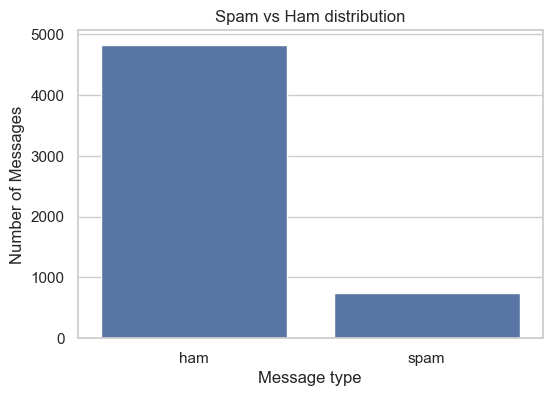

In [10]:
# Visualize Class Distribution using counplot graph between spam and ham sms
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label")
plt.title("Spam vs Ham distribution")
plt.xlabel("Message type")
plt.ylabel("Number of Messages")
plt.show()

#Converting labels to binary numbers

In [11]:
#Map text labels to binary integers where (0=ham and 1=spam)
df["label_num"]=df["label"].map({"ham": 0,"spam": 1})
df.head()

,label,messages,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [12]:
#checking the label counts of different columns
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

#Text prprocessing

In [13]:
# Load English stopwords
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    # Join words back together
    return " ".join(words)


#Applying the function

In [14]:
df["clean_messages"] = df["messages"].apply(preprocess_text)
df[["messages", "clean_messages"]].head()

,messages,clean_messages
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


#Term Frequency (TF) measures how frequently a word occurs in a particular document.

Inverse Document Frequency (IDF) measures how important a word is by reducing the weight of words that occur in many documents.

Therefore, TF-IDF gives a high value to words that are important to a particular message but do not appear frequently across the entire dataset.

In spam detection, words such as "free", "winner", "prize", or "claim" may receive relatively high TF-IDF values when they help distinguish spam messages from legitimate messages.

#Train test split

In [15]:
#Splitting data into train and test(dependant and indipent)
X = df["clean_messages"]
y = df["label_num"]

In [16]:
#Training and testing the data
X_train, X_test, y_train, y_test = train_test_split( X, y,test_size=0.20,random_state=42, stratify=y)
print(X_train)
print(X_test)

184                               going nothing great bye
2171                                    wont wat wit guys
5422                          ok k sry knw siva tats askd
4113           stand away heart ache without wonder crave
4588                          finished work yet something
                              ...                        
1932                            jus finished avatar nigro
5316                             jus finish watching tv u
2308    moby pub quiz win high street prize u know new...
1903    free entry weekly comp chance win ipod txt pod...
763     nothing jus tot u would ask cos u ba gua went ...
Name: clean_messages, Length: 4457, dtype: object
2826    oh right ok make sure loads work day got reall...
3695                                      tirupur call da
3906                                       means fat head
575                                 cash prize claim call
2899               come aftr lt decimal gt cleaning house
                      

#TF-IDF Vectorization

In [17]:
tfidf = TfidfVectorizer( max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print( X_train_tfidf.shape)
print( X_test_tfidf.shape)

(4457, 5000)
(1115, 5000)


In [18]:
#we use this tranformation in training data and testing data to prevent test set leaking into training process
tfidf.fit_transform(X_train)

<4457x5000 sparse matrix of type '<class 'numpy.float64'>'
	with 40289 stored elements in Compressed Sparse Row format>

In [19]:
tfidf.fit_transform(X_test)

<1115x5000 sparse matrix of type '<class 'numpy.float64'>'
	with 12012 stored elements in Compressed Sparse Row format>

#Model 1 — Multinomial Naive Baye

In [20]:
# Creating Naive Bayes model
nb_model = MultinomialNB()

In [21]:
# Training model
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [22]:
# Model predictions
nb_pred = nb_model.predict(X_test_tfidf)

#Evaluating the model

In [23]:
print("Multinomial Naive Bayes")
print("=" * 40)

print("Accuracy :", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall   :", recall_score(y_test, nb_pred))
print("F1 Score :", f1_score(y_test, nb_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    nb_pred,
    target_names=["Ham", "Spam"]
))

Multinomial Naive Bayes
Accuracy : 0.9704035874439462
Precision: 0.9915254237288136
Recall   : 0.785234899328859
F1 Score : 0.8764044943820225

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.99      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



#Naive Bayes confusion matrix

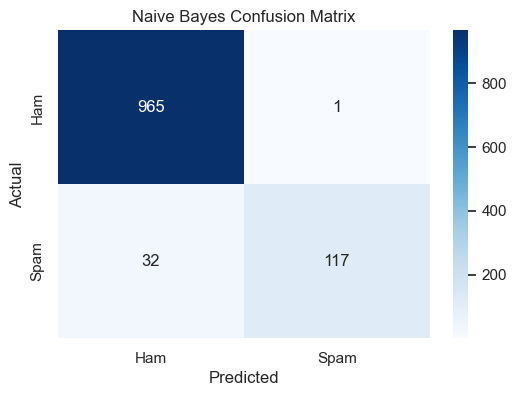

In [24]:
cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#Model 2 — Logistic Regression

In [25]:
# Creating Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

<IPython.core.display.Javascript object>

In [26]:
# Train model
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [27]:
# Make predictions
lr_pred = lr_model.predict(X_test_tfidf)

#Evaluating the model

In [28]:
print("Logistic Regression")
print("=" * 40)

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    lr_pred,
    target_names=["Ham", "Spam"]
))

Logistic Regression
Accuracy : 0.9695067264573991
Precision: 0.9752066115702479
Recall   : 0.7919463087248322
F1 Score : 0.8740740740740741

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.98      0.79      0.87       149

    accuracy                           0.97      1115
   macro avg       0.97      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



#Logistic Regression confusion matrix

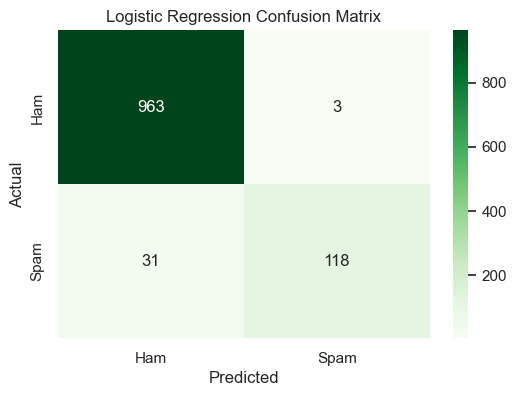

In [29]:
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#Comparing both models

In [30]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred)
    ],
    
    "Precision": [
        precision_score(y_test, nb_pred),
        precision_score(y_test, lr_pred)
    ],
    
    "Recall": [
        recall_score(y_test, nb_pred),
        recall_score(y_test, lr_pred)
    ],
    
    "F1 Score": [
        f1_score(y_test, nb_pred),
        f1_score(y_test, lr_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.970404,0.991525,0.785235,0.876404
1,Logistic Regression,0.969507,0.975207,0.791946,0.874074


#Visualizing the comparison of the two models

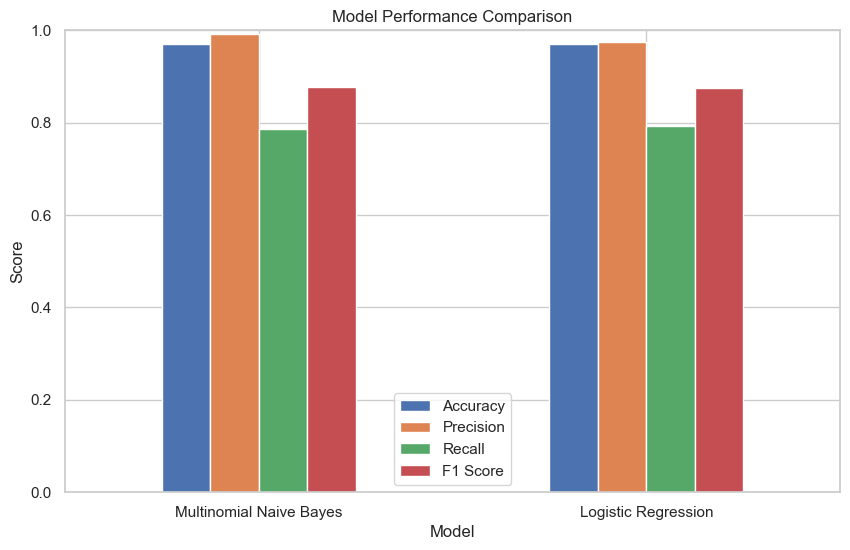

In [31]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

Why is Recall Important in Spam Detection?

Recall is particularly important in spam detection because it measures the percentage of actual spam messages that the model correctly identifies as spam